In [1]:
import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3

import calmly

# `calmly`: Cavity alignment with ML

## Appendix: `calmly.simulator`
- Simulates the process of aligning any optical cavity to a laser beam with two steering mirrors
- Works with models of arbitrary cavities created in [Finesse 3](https://finesse.ifosim.org/docs/latest/).
- Produces cavity scans that can be used to teach the reinforcement learning agents
- `Piezomotor` class for simulating the action of piezoelectric stick-slip motors

### Example: a two-mirror cavity
![](./cavalign_example_schematic.png)

We are going to use a special-case constructor for `CavityAlignment`, `calmly.CavityAlignment.two_mirror_cavity()`, which automatically creates and stores the Finesse model of a two-mirror (Fabry-Perot) cavity from the given parameters. It is possible to use the general constructor `calmly.CavityAlignment()` instead in order to simulate cavities represented by arbitrary custom Finesse models. 

In [3]:
cav_align = calmly.CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(11) # Number of TEM modes to include in the simulation

#### Misaligning the input coupler by 300 urad and producing a cavity scan:
We change the yaw angle of the input cavity mirror IC by $\alpha=3\times 10^{-4}$ rad and take a cavity scan by changing the laser frequency and looking at the DC readout of the photodetector in transmission. Note that by default the `.cavity_scan()` method changes the frequency over 2.1 free spectral ranges (FSRs) of the optical cavity. This can be changed by passing a `scan_range_in_fsrs` parameter to `.cavity_scan()`. See the help for this method for more details.

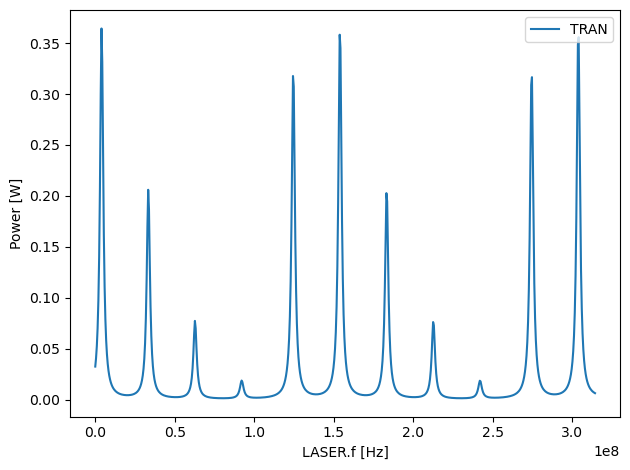

In [4]:
cav_align.m.IC.xbeta = 3e-4
cav_align.cavity_scan(ppbw_resolution = 5, plot=True);

#### Compensating for the IC misalignment by turning steering mirror 2 by 150 urad:
Since SM2 happens to be at the centre of curvature of the curved cavity mirror OC, the misalignment we created by turning the plane input cavity mirror IC by $\alpha=3\times 10^{-4}$ rad can be compensated for by turning SM2 in the same direction by $\alpha/2$. When we do that, indeed only the TEM00 peaks remain visible in the cavity scan:

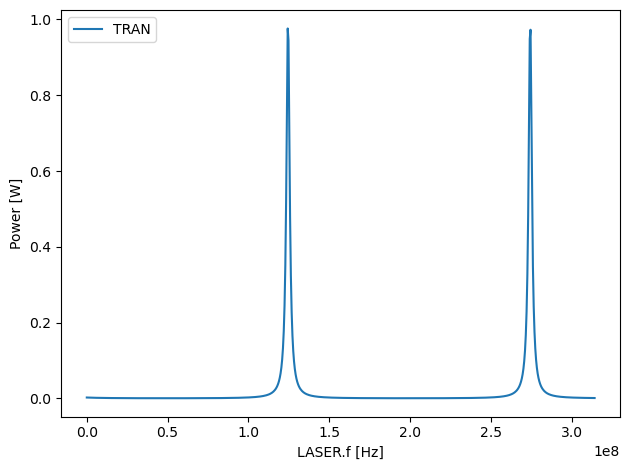

In [5]:
cav_align.sm2.xbeta = 1.5e-4
cav_align.cavity_scan(ppbw_resolution = 5, plot=True);

### Convergence testing
Including a sufficient number of TEM modes is crucial for the simulation to generate realistic cavity scans. There should be enough modes to adequately describe the shifted and misaligned beams in a fixed TEM mode basis. The convergence breaks down quickly when the misalignment angles are increased.

The `.get_convergence_curves()` method misaligns a selected optical component in the model to aid with selecting the right amount of TEM modes. Note that the Finesse parameter `maxtem` selects the highest _order_ of TEM modes to be included, not the total number of modes (i.e. `maxtem=19` will include 210 modes in total). Then the selected detectors are plotted, e.g. in our example the first plot is the sum of reflected and transmitted power by the cavity. When this value is not close to 1, this means that the power is lost into unaccounted modes. The plots show that the required amount of modes grows quickly with increasing angles. Note, however, that the signal in transmission near the resonance requires less modes to converge, since the calculation is done in the cavity basis and the cavity is assumed to belocked to the TEM00 mode, thus filtering the others.

maxtem=1 calculation finished
maxtem=3 calculation finished
maxtem=7 calculation finished
maxtem=11 calculation finished
maxtem=15 calculation finished
maxtem=19 calculation finished


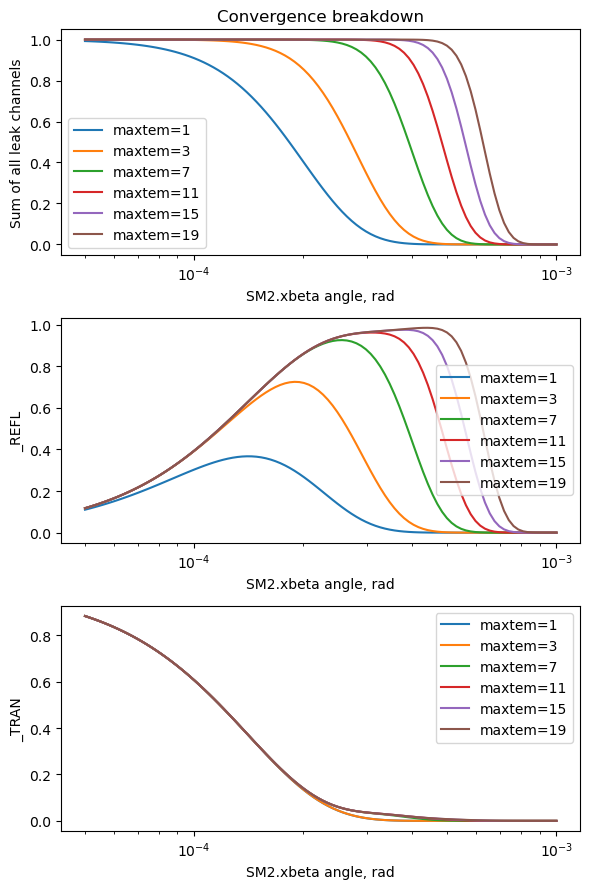

In [6]:
cav_align.m.IC.xbeta = 0
cav_align.sm2.xbeta = 0

cav_align.get_convergence_curves(axis = cav_align.sm2.xbeta,
                                 x = np.geomspace(5e-5,1e-3,100),
                                 maxtem_list = [1, 3, 7, 11, 15, 19],
                                 cavity_leak_channels = [cav_align.m.IC.p1.o, cav_align.m.OC.p2.o],
                                 leak_channel_names = ['_REFL', '_TRAN'],
                                 lock_to_mode=[0,0],
                                 plot = 'all',
                                 plot_logx = True
                                );

### Motors
The model can simulate the effect of piezoelectric stick-slip motors (e.g. the Picomotors) attached to the steering mirrors' pitch and yaw axes. Note that these motors typically have different calibration coefficients (in units of rad/count) for the positive and negative directions.

In [7]:
# attaching identical motors to all alignment degrees of freedom
cav_align.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=0.9e-6, uncertainty=0.1)

Moving a motor forward and back by the same number of counts will not restore the corresponding alignment angle:

In [8]:
print(cav_align.dof_info(cav_align.sm2.xbeta))
print("Moving SM2.xbeta motor by +100 counts")
cav_align.move_steering_motor(cav_align.sm2.xbeta, 100)
print(cav_align.dof_info(cav_align.sm2.xbeta))
print("Moving SM2.xbeta motor by -100 counts")
cav_align.move_steering_motor(cav_align.sm2.xbeta, -100)
print(cav_align.dof_info(cav_align.sm2.xbeta))

SM2.xbeta = 0.0 radians, motor pos = 0
Moving SM2.xbeta motor by +100 counts
SM2.xbeta = 0.0001095909850980895 radians, motor pos = 100
Moving SM2.xbeta motor by -100 counts
SM2.xbeta = 1.8595079399890546e-05 radians, motor pos = 0


In [7]:
cav_sim_factory, scan_processor_factory = calmly.load_factories("my_factories.py")

create_env = calmly.get_env_factory(
    cav_sim_factory=cav_sim_factory,
    scan_processor_factory=scan_processor_factory,
    monitor=False,
    training=False,
    mis_angle_min=-2e-4,
    mis_angle_max=2e-4
)

In [10]:
model = stable_baselines3.PPO.load("ppo_training")

test_env = create_env()

out = calmly.simulate_episode_with_trained_model(model, test_env)

Total Episode Reward: 666.2476324036825
Finished as Terminated after 46 steps
Final dominance of the main peak: 0.8245027105914587


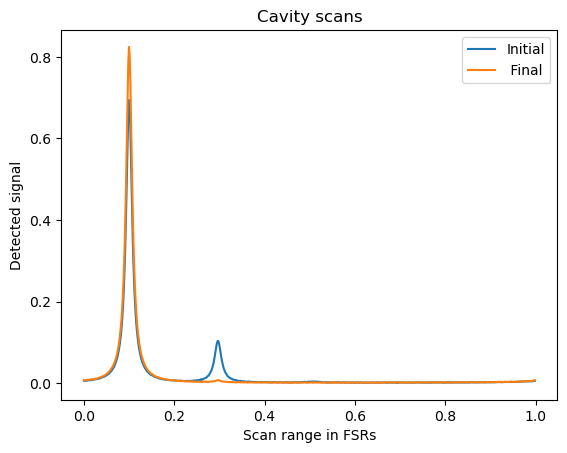

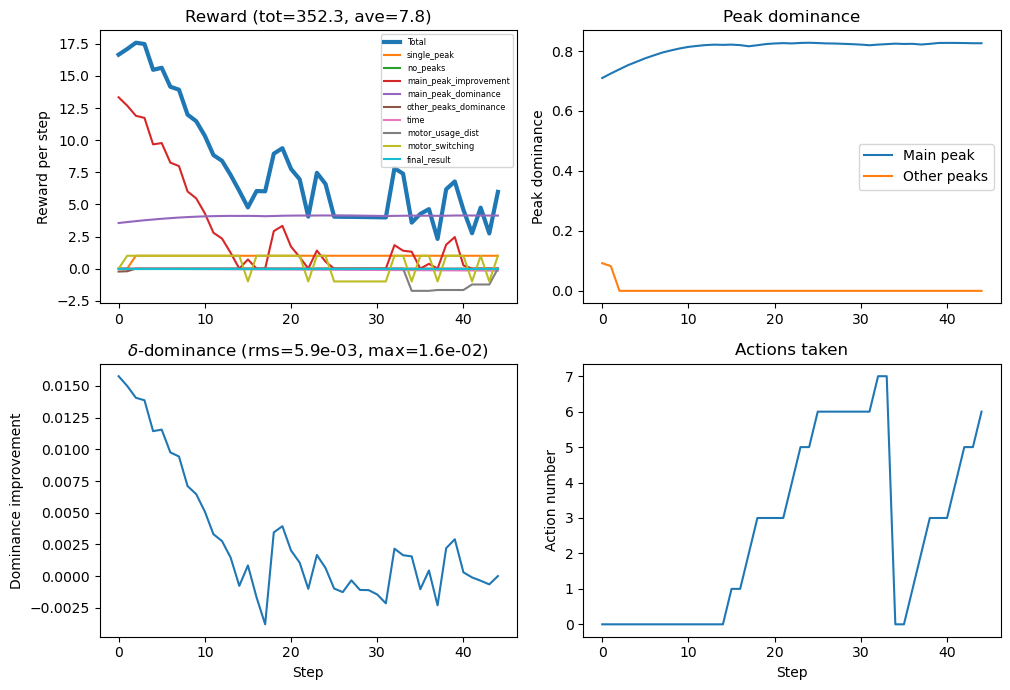

In [11]:
out.plot_cavity_scans();
out.plot_metrics(step_highlim=-1);

In [13]:
test_env = create_env()
diag = calmly.manual_episode_init(test_env)

step: 0 	rew: None 	dom: 0.7450843696309456 	ddom: None 	Npeaks: 2


In [133]:
calmly.manual_episode_step(test_env, diag, action=None)

step: 117 	rew: None 	dom: 0.8316687775284975 	ddom: -0.00010064024341716049 	Npeaks: 1


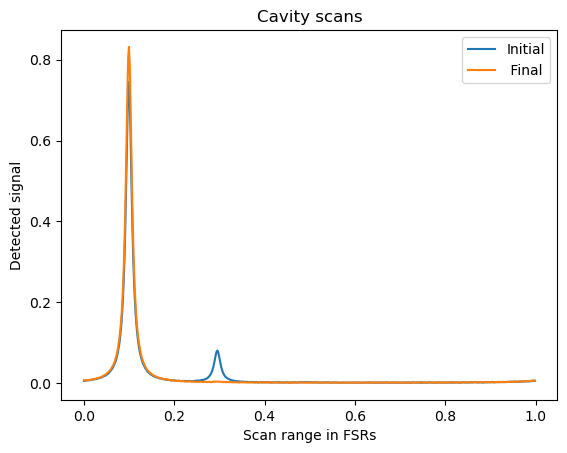

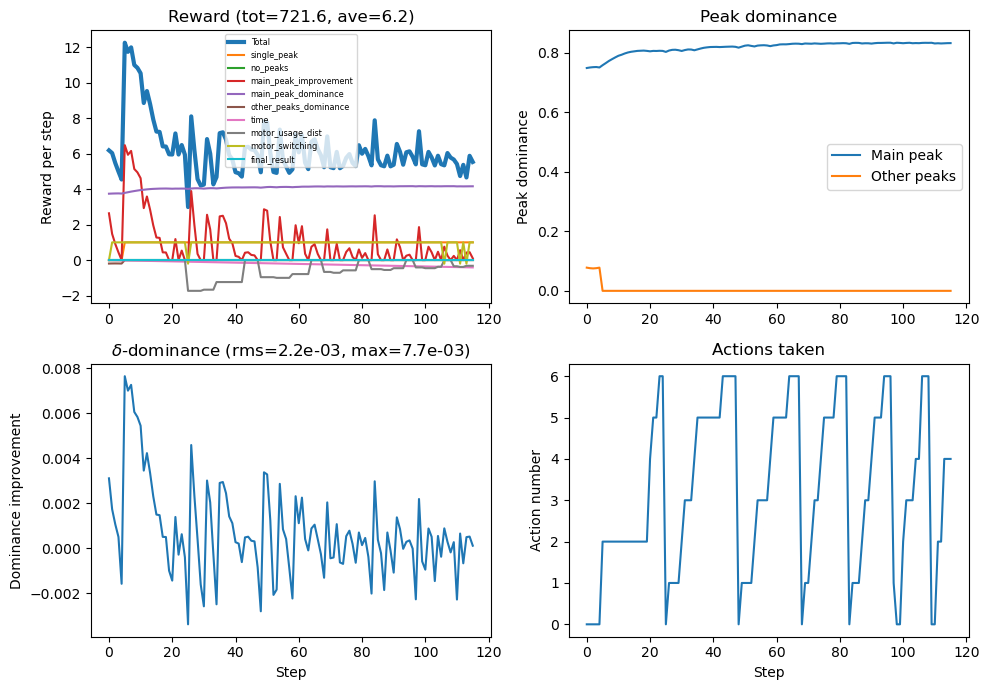

In [135]:
diag.plot_cavity_scans();
diag.plot_metrics(step_highlim=-1);

In [ ]:
calmly.actions.generate_dataset("calmly_config.yaml")

In [ ]:
calmly.actions.train_bc_model("calmly_config.yaml")

In [ ]:
calmly.actions.train_ppo_model("calmly_config.yaml")